# XGBoost / LightGBM Model + SHAP Explainability
**Project:** Agri Price Forecast | **Author:** Monisha

This notebook:
1. Trains XGBoost and LightGBM on the full feature matrix
2. Evaluates vs SARIMA baseline and LSTM
3. Generates SHAP feature importance (key for paper)
4. Saves model and SHAP values for dashboard

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import json
import warnings
warnings.filterwarnings('ignore')

from src.models.xgboost_model import XGBoostModel, FEATURE_COLS
from src.models.evaluate import evaluate_all, compare_models
from src.utils.config import MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT_NAME
import mlflow

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete')

c:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete


In [2]:
feat_df = pd.read_csv('../data/processed/features_onion.csv', parse_dates=['date'])
feat_df = feat_df.sort_values('date').reset_index(drop=True)

# Date-based split
train_val = feat_df[feat_df['date'] < '2025-01-01'].copy()
test_df   = feat_df[feat_df['date'] >= '2025-01-01'].copy()

n_tv  = len(train_val)
n_val = int(n_tv * 0.20)
train_df = train_val.iloc[:-n_val].copy()
val_df   = train_val.iloc[-n_val:].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train mean: ₹{train_df['modal_price'].mean():.0f}")
print(f"Test mean:  ₹{test_df['modal_price'].mean():.0f}")

Train: 6872 | Val: 1718 | Test: 126
Train mean: ₹1167
Test mean:  ₹2225


In [3]:
feat_df = pd.read_csv('../data/processed/features_onion.csv', parse_dates=['date'])
feat_df = feat_df.sort_values('date').reset_index(drop=True)
print(f'Feature matrix: {feat_df.shape}')

available_features = [c for c in FEATURE_COLS if c in feat_df.columns]
print(f'Available features: {len(available_features)}')

Feature matrix: (8716, 66)
Available features: 30


## 1. Train XGBoost

In [ ]:
print('Training XGBoost...')
xgb_model = XGBoostModel(
    backend='xgboost',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
)
xgb_model.fit(train_val, target_col='target_1d')
xgb_metrics = xgb_model.evaluate_on_test(test_df, target_col='target_1d')

print('\n=== XGBOOST METRICS ===')
for k, v in xgb_metrics.items():
    if k != 'model':
        print(f'{k.upper()}: {v:.4f}')

Training XGBoost...
2026-06-05 14:23:24 | INFO     | src.models.xgboost_model | xgboost training complete
2026-06-05 14:23:24 | INFO     | src.models.evaluate | [XGBOOST] RMSE=503.04 | MAE=339.11 | MAPE=16.57% | SMAPE=15.13% | R2=0.0359

=== XGBOOST METRICS ===
RMSE: 503.0391
MAE: 339.1140
MAPE: 16.5684
SMAPE: 15.1335
R2: 0.0359


## 2. Train LightGBM

In [ ]:
print('Training LightGBM...')
lgb_model = XGBoostModel(
    backend='lightgbm',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
)
lgb_model.fit(train_val, target_col='target_1d')
lgb_metrics = lgb_model.evaluate_on_test(test_df, target_col='target_1d')

print('\n=== LIGHTGBM METRICS ===')
for k, v in lgb_metrics.items():
    if k != 'model':
        print(f'{k.upper()}: {v:.4f}')

Training LightGBM...
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6516
[LightGBM] [Info] Number of data points in the train set: 5978, number of used features: 34
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Start training from score 1035.915924
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

## 3. SHAP Feature Importance

Computing SHAP values...


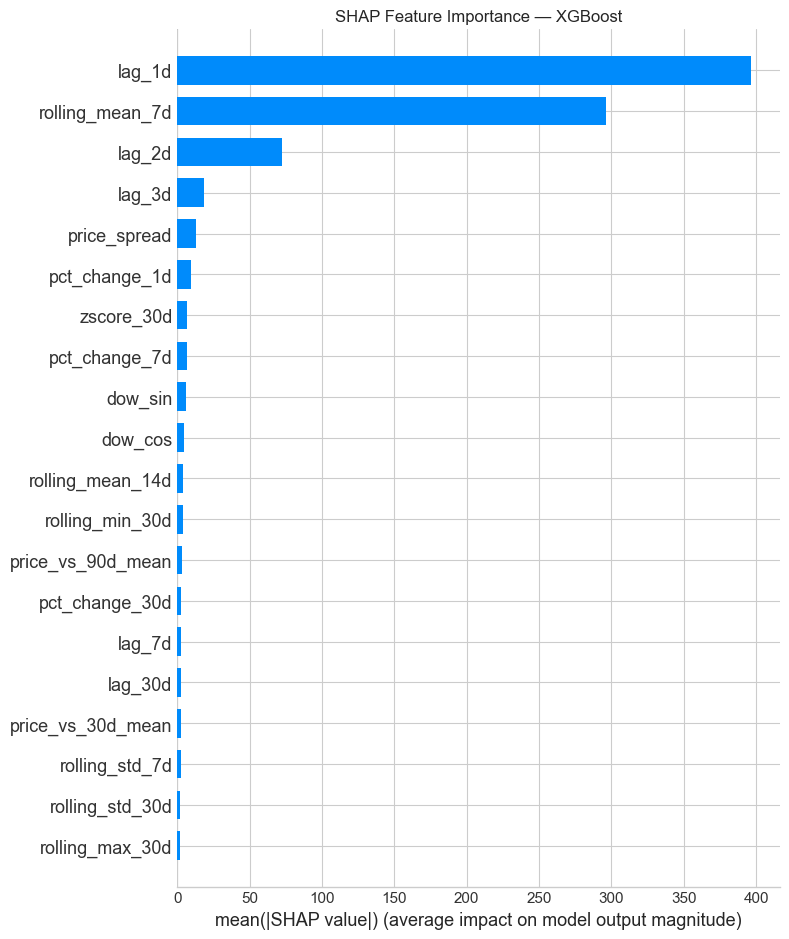

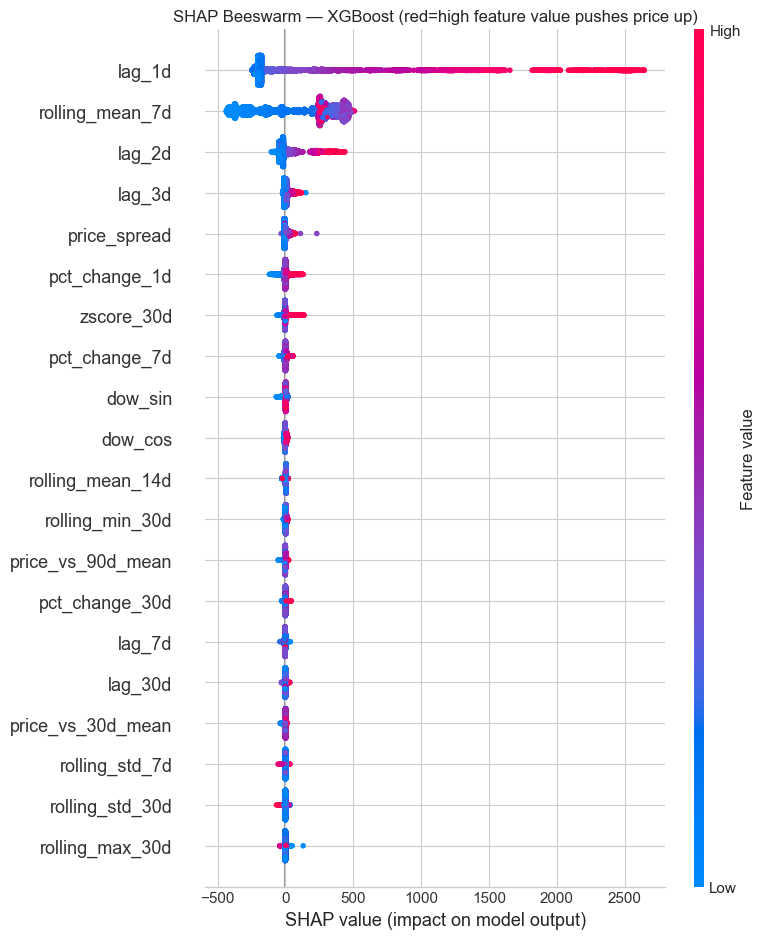

In [6]:
print('Computing SHAP values...')
shap_vals, X_data, feature_names = xgb_model.get_shap_values(feat_df)

# Summary plot (bar)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_data, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('../docs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot (shows direction of impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_data, feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm — XGBoost (red=high feature value pushes price up)')
plt.tight_layout()
plt.savefig('../docs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SHAP Dependence Plots (top 3 features)

Top 3 features: ['lag_1d', 'rolling_mean_7d', 'lag_2d']


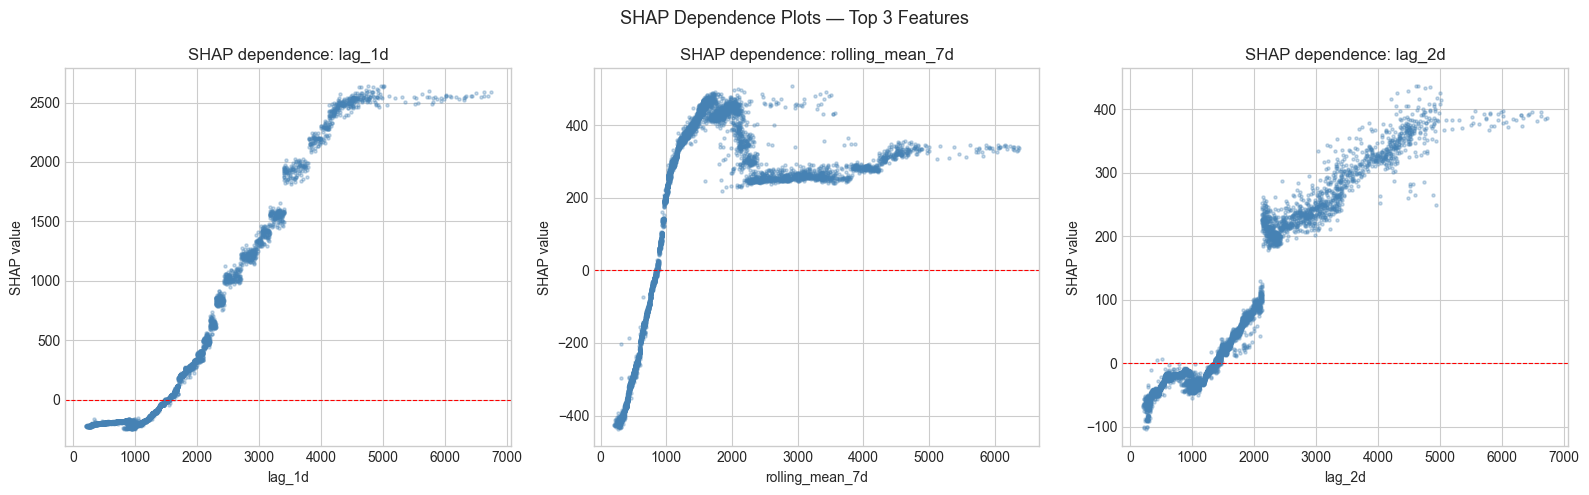

In [7]:
# Get top 3 features by mean |SHAP|
mean_shap = np.abs(shap_vals).mean(axis=0)
top3_idx  = mean_shap.argsort()[-3:][::-1]
top3_feat = [feature_names[i] for i in top3_idx]
print(f'Top 3 features: {top3_feat}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top3_feat):
    feat_idx = feature_names.index(feat)
    ax.scatter(X_data[:, feat_idx], shap_vals[:, feat_idx], alpha=0.3, s=5, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'SHAP dependence: {feat}')

plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Models and Metrics

In [8]:
xgb_model.save()
lgb_model.save()

with open('../docs/metrics_xgboost.json', 'w') as f:
    json.dump(xgb_metrics, f, indent=2)
with open('../docs/metrics_lightgbm.json', 'w') as f:
    json.dump(lgb_metrics, f, indent=2)

print('Models saved.')

2026-06-05 14:23:38 | INFO     | src.models.xgboost_model | Saved: C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\models\xgboost_onion_v1.pkl
2026-06-05 14:23:38 | INFO     | src.models.xgboost_model | Saved: C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\models\lightgbm_onion_v1.pkl
Models saved.


## 6. Full Comparison Table

=== FULL MODEL COMPARISON ===
            model    rmse     mae   mape  smape     r2
SARIMA (Baseline) 304.710 128.471  5.760  5.728  0.604
             LSTM 457.181 216.759  9.336  8.774  0.750
              GRU 500.692 344.271 16.434 15.422 -0.258
          XGBoost 503.039 339.114 16.568 15.134  0.036
         LightGBM 529.295 358.435 17.550 15.746 -0.067


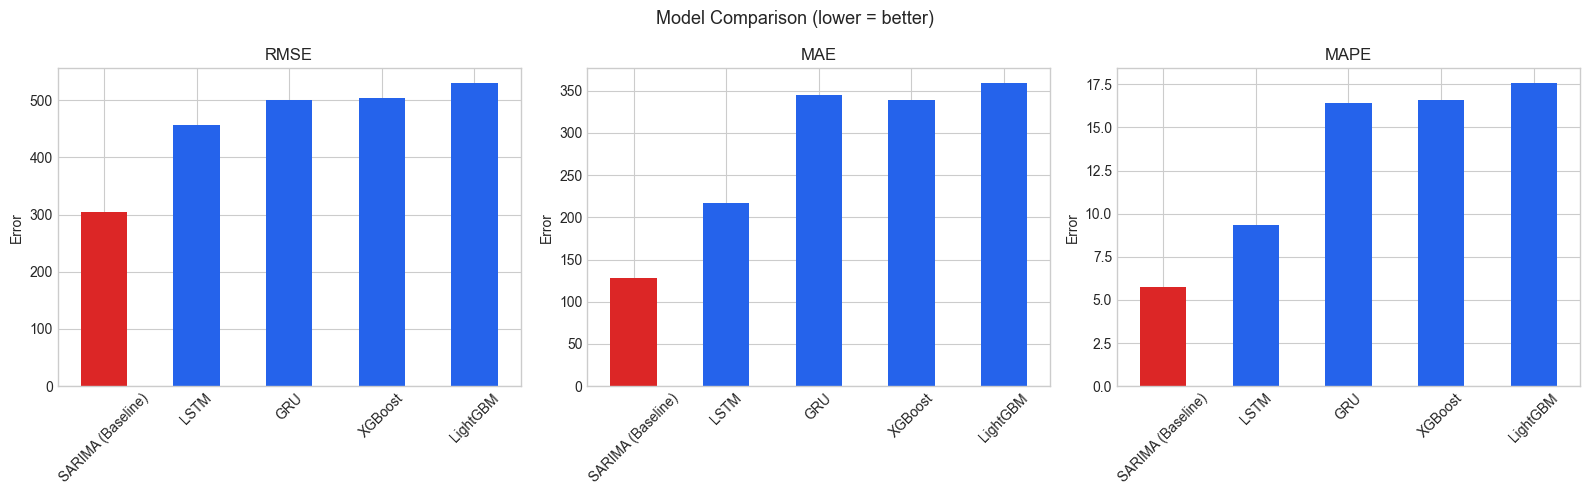

In [9]:
all_metrics = []
files = [
    ('../docs/metrics_sarima.json',   'SARIMA (Baseline)'),
    ('../docs/metrics_lstm.json',     'LSTM'),
    ('../docs/metrics_gru.json',      'GRU'),
    ('../docs/metrics_xgboost.json',  'XGBoost'),
    ('../docs/metrics_lightgbm.json', 'LightGBM'),
]
for fname, label in files:
    try:
        with open(fname) as f:
            m = json.load(f)
            m['model'] = label
            all_metrics.append(m)
    except FileNotFoundError:
        print(f'Missing: {fname}')

if all_metrics:
    summary = pd.DataFrame(all_metrics)[['model','rmse','mae','mape','smape','r2']].round(3)
    summary = summary.sort_values('rmse')
    print('=== FULL MODEL COMPARISON ===')
    print(summary.to_string(index=False))
    summary.to_csv('../docs/model_comparison.csv', index=False)

    # Bar chart
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colours = ['#DC2626' if i==0 else '#2563EB' for i in range(len(summary))]
    for ax, metric in zip(axes, ['rmse','mae','mape']):
        summary.plot(kind='bar', x='model', y=metric, ax=ax, color=colours, legend=False)
        ax.set_title(metric.upper())
        ax.set_ylabel('Error')
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('')
    plt.suptitle('Model Comparison (lower = better)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../docs/model_comparison_chart.png', dpi=150, bbox_inches='tight')
    plt.show()